Funnel Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

Corporate Styling

In [4]:
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
print("Everything is fine")

Everything is fine


Load Dataset

In [6]:
df = pd.read_csv(r"C:\Users\93sha\Downloads\funnel_analysis_data.csv")
df.head(10)

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.00,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.00,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.00,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.00,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.00,No
5,USR00002,SES00002,Checkout,2025-10-19 09:23:10,Desktop,North,Social Media,Fashion,0.00,No
6,USR00002,SES00002,Purchase,2025-10-19 09:27:10,Mobile,North,Google Ads,Sports,448.18,No
7,USR00003,SES00003,Browse,2025-10-12 02:19:00,Desktop,East,Google Ads,Beauty,0.00,No
8,USR00003,SES00003,Add to Cart,2025-10-12 02:22:00,Tablet,South,Social Media,Beauty,0.00,No
9,USR00003,SES00003,Checkout,2025-10-12 02:26:00,Desktop,West,Google Ads,Sports,0.00,No


In [7]:
## Basic Analysis
df.tail(10)

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
21653,USR09996,SES09996,Purchase,2025-10-24 13:55:03,Mobile,North,Social Media,Fashion,1997.47,No
21654,USR09997,SES09997,Browse,2025-10-28 02:53:54,Mobile,South,Google Ads,Home,0.00,Yes
21655,USR09998,SES09998,Browse,2025-10-09 12:04:15,Tablet,East,Social Media,Beauty,0.00,Yes
21656,USR09998,SES09998,Add to Cart,2025-10-09 12:06:15,Desktop,South,Email,Home,0.00,Yes
21657,USR09998,SES09998,Checkout,2025-10-09 12:08:15,Tablet,East,Email,Fashion,0.00,Yes
21658,USR09999,SES09999,Browse,2025-10-03 17:22:58,Desktop,South,Google Ads,Electronics,0.00,No
21659,USR09999,SES09999,Add to Cart,2025-10-03 17:26:58,Tablet,West,Social Media,Fashion,0.00,No
21660,USR09999,SES09999,Checkout,2025-10-03 17:29:58,Mobile,North,Email,Fashion,0.00,No
21661,USR09999,SES09999,Purchase,2025-10-03 17:34:58,Mobile,East,Email,Fashion,960.65,No
21662,USR10000,SES10000,Browse,2025-10-15 20:32:43,Mobile,South,Google Ads,Beauty,0.00,Yes


In [8]:
df.describe()

,Revenue
count,21663.000000
mean,54.304841
std,262.692471
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1998.510000


In [9]:
df.shape

(21663, 10)

In [10]:
## Timestamp column must be in the date time type
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.dtypes)

User_ID                     object
Session_ID                  object
Event                       object
Timestamp           datetime64[ns]
Device                      object
Region                      object
Channel                     object
Product_Category            object
Revenue                    float64
Bounce_Flag                 object
dtype: object


In [11]:
## Information about all columns
df.describe(include="object")

,User_ID,Session_ID,Event,Device,Region,Channel,Product_Category,Bounce_Flag
count,21663,21663,21663,21663,21663,21663,21663,21663
unique,10000,10000,4,3,4,4,5,2
top,USR07731,SES07731,Browse,Tablet,West,Google Ads,Electronics,Yes
freq,4,4,10000,7237,5462,5435,4405,17343


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   User_ID           21663 non-null  object        
 1   Session_ID        21663 non-null  object        
 2   Event             21663 non-null  object        
 3   Timestamp         21663 non-null  datetime64[ns]
 4   Device            21663 non-null  object        
 5   Region            21663 non-null  object        
 6   Channel           21663 non-null  object        
 7   Product_Category  21663 non-null  object        
 8   Revenue           21663 non-null  float64       
 9   Bounce_Flag       21663 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(8)
memory usage: 1.7+ MB


In [13]:
df.describe()

,Timestamp,Revenue
count,21663,21663.000000
mean,2025-10-16 19:56:22.920740608,54.304841
min,2025-10-01 19:30:17,0.000000
25%,2025-10-09 08:31:38,0.000000
50%,2025-10-16 19:47:21,0.000000
75%,2025-10-24 08:13:17,0.000000
max,2025-10-31 19:25:15,1998.510000
std,NaN,262.692471


In [14]:
pd.set_option("display.max_rows", None)

In [15]:
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


Data Preprocessing and Cleaning

In [17]:
## check for NULL VALUES if present in a Null values 
df.isnull().sum()

print("\n")

## Check for duplicate values
df.duplicated().sum()

print("\n")

## Check for unique values
df.nunique()

User_ID             10000
Session_ID          10000
Event                   4
Timestamp           21564
Device                  3
Region                  4
Channel                 4
Product_Category        5
Revenue              1078
Bounce_Flag             2
dtype: int64

In [18]:
## Now fixing the data and extracting time based data 
## Now we can analyze the data more efficiently

df['Date'] = df['Timestamp'].dt.date
df['DayOfWeek'] = df['Timestamp'].dt.day_name()
df['Hour'] = df['Timestamp'].dt.hour
df['WeekNumber'] = df['Timestamp'].dt.isocalendar().week

In [19]:
df.head(10)

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Date,DayOfWeek,Hour,WeekNumber
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.00,Yes,2025-10-28,Tuesday,7,44
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.00,Yes,2025-10-28,Tuesday,7,44
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.00,Yes,2025-10-28,Tuesday,7,44
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.00,No,2025-10-19,Sunday,9,42
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.00,No,2025-10-19,Sunday,9,42
5,USR00002,SES00002,Checkout,2025-10-19 09:23:10,Desktop,North,Social Media,Fashion,0.00,No,2025-10-19,Sunday,9,42
6,USR00002,SES00002,Purchase,2025-10-19 09:27:10,Mobile,North,Google Ads,Sports,448.18,No,2025-10-19,Sunday,9,42
7,USR00003,SES00003,Browse,2025-10-12 02:19:00,Desktop,East,Google Ads,Beauty,0.00,No,2025-10-12,Sunday,2,41
8,USR00003,SES00003,Add to Cart,2025-10-12 02:22:00,Tablet,South,Social Media,Beauty,0.00,No,2025-10-12,Sunday,2,41
9,USR00003,SES00003,Checkout,2025-10-12 02:26:00,Desktop,West,Google Ads,Sports,0.00,No,2025-10-12,Sunday,2,41


In [20]:
df["Event_Sequence"] = df.groupby("Session_ID").cumcount() + 1

In [21]:
df.head()

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Date,DayOfWeek,Hour,WeekNumber,Event_Sequence
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes,2025-10-28,Tuesday,7,44,1
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes,2025-10-28,Tuesday,7,44,2
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes,2025-10-28,Tuesday,7,44,3
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No,2025-10-19,Sunday,9,42,1
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No,2025-10-19,Sunday,9,42,2


In [22]:
## To basically find the unique values for userID and session
print(f"Total User ID {df["User_ID"].nunique()}")
print(f"Total Session ID {df["Session_ID"].nunique()}")
print("\n")
print(f"\n Date Range {df["Date"].min()} to {df["Date"].max()}")

Total User ID 10000
Total Session ID 10000



 Date Range 2025-10-01 to 2025-10-31


## Funnel Stage Defination and Session-Level Aggregation

In [49]:
## Define funnel stages in order
funnel_stages = ["Browse", "Add to cart", "Checkout", "Purchase"]

session_summary = df.groupby("Session_ID").agg({
    "User_ID": "first",
    "Timestamp": ["min", "max"],
    "Event": lambda x: list(x),
    "Device": "first",
    "Region": "first",
    "Channel": "first",
    "Product_Category": "first",
    "Revenue": "max",   # or "sum"
    "Bounce_Flag": "first"
}).reset_index()

session_summary.columns = [
    "Session_ID", "User_ID", "Session_Start", "Session_End",
    "Event_Sequence", "Device", "Region", "Channel",
    "Product_Category", "Revenue", "Bounce_Flag"
]

session_summary["Session_Duration_Min"] = (
    session_summary["Session_End"] - session_summary["Session_Start"]
).dt.total_seconds() / 60

def get_max_funnel_stage(events):
    stage_values = {stage: i for i, stage in enumerate(funnel_stages)}
    max_stage_index = -1
    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index = stage_values[event]
    return funnel_stages[max_stage_index] if max_stage_index != -1 else "Browse"

session_summary["Max_Funnel_Stage"] = (
    session_summary["Event_Sequence"].apply(get_max_funnel_stage)
)

print("Session Summary Created:")
display(session_summary.head(10))

Session Summary Created:


,Session_ID,User_ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES00001,USR00001,2025-10-28 07:33:50,2025-10-28 07:40:50,"[Browse, Add to Cart, Checkout]",Desktop,West,Organic,Home,0.00,Yes,7.0,Checkout
1,SES00002,USR00002,2025-10-19 09:15:10,2025-10-19 09:27:10,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Email,Electronics,448.18,No,12.0,Purchase
2,SES00003,USR00003,2025-10-12 02:19:00,2025-10-12 02:29:00,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,East,Google Ads,Beauty,1437.19,No,10.0,Purchase
3,SES00004,USR00004,2025-10-05 17:55:48,2025-10-05 17:55:48,[Browse],Tablet,West,Social Media,Home,0.00,Yes,0.0,Browse
4,SES00005,USR00005,2025-10-19 12:35:49,2025-10-19 12:37:49,"[Browse, Add to Cart]",Tablet,West,Google Ads,Electronics,0.00,Yes,2.0,Browse
5,SES00006,USR00006,2025-10-06 13:20:53,2025-10-06 13:20:53,[Browse],Tablet,North,Email,Beauty,0.00,Yes,0.0,Browse
6,SES00007,USR00007,2025-10-20 15:23:11,2025-10-20 15:23:11,[Browse],Mobile,South,Google Ads,Home,0.00,Yes,0.0,Browse
7,SES00008,USR00008,2025-10-13 12:59:29,2025-10-13 13:10:29,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,West,Google Ads,Beauty,304.30,No,11.0,Purchase
8,SES00009,USR00009,2025-10-17 10:27:10,2025-10-17 10:30:10,"[Browse, Add to Cart]",Tablet,South,Organic,Fashion,0.00,Yes,3.0,Browse
9,SES00010,USR00010,2025-10-30 17:23:31,2025-10-30 17:23:31,[Browse],Desktop,West,Email,Sports,0.00,Yes,0.0,Browse


In [59]:
## Calculate Overall funnel metrics
funnel_metrics = []
for i, stage in enumerate(funnel_stages):
    if i == 0:
        ## for Browse stage, count all sessions
        count = len(session_summary)
    else:
        ## for other stages, count sessions that reached at least this stage
        count = len(session_summary[session_summary["Max_Funnel_Stage"].isin(funnel_stages[i:])])

    funnel_metrics.append({
        "Stage": stage,
        "Sessions": count,
        "Stage_Order": i
    })

funnel_df = pd.DataFrame(funnel_metrics)

## Calculate conversion rates
funnel_df["Conversion_Rate"] = (funnel_df["Sessions"] / funnel_df["Sessions"].iloc[0] * 100).round(2)
funnel_df["Drop_Off_Rate"] = (1 - funnel_df["Sessions"] / funnel_df["Sessions"].shift(1)) * 100
funnel_df.loc[0, "Drop_Off_Rate"] = 0
funnel_df["Drop_Off_Rate"] = funnel_df["Drop_Off_Rate"].round(2)

print("Overall Funnel Analysis : ")
display(funnel_df)

Overall Funnel Analysis : 


,Stage,Sessions,Stage_Order,Conversion_Rate,Drop_Off_Rate
0,Browse,10000,0,100.00,0.00
1,Add to cart,3524,1,35.24,64.76
2,Checkout,3524,2,35.24,0.00
3,Purchase,1080,3,10.80,69.35


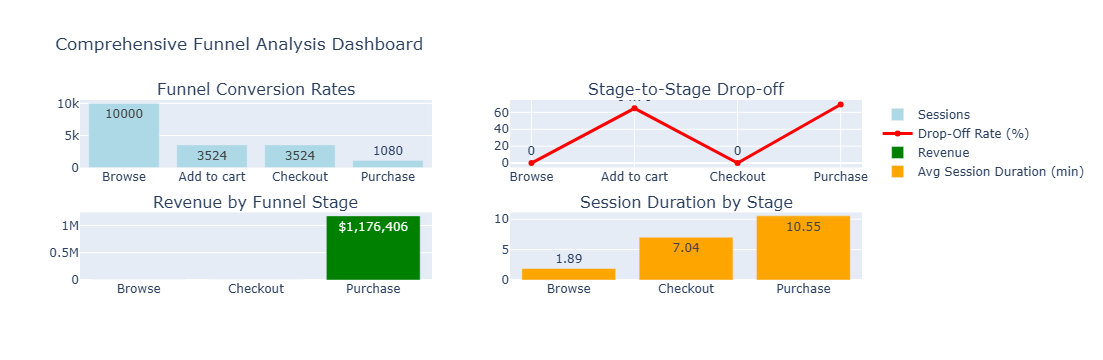

In [71]:
## Create Comprehensive funnel Visualization
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Funnel Conversion Rates",
        "Stage-to-Stage Drop-off",
        "Revenue by Funnel Stage",
        "Session Duration by Stage"
    )
)

# Funnel conversion rates
fig.add_trace(
    go.Bar(
        x=funnel_df["Stage"],
        y=funnel_df["Sessions"],
        text=funnel_df["Sessions"],
        textposition="auto",
        name="Sessions",
        marker_color="lightblue"
    ),
    row=1, col=1
)

# Drop-Off Rates
fig.add_trace(
    go.Scatter(
        x=funnel_df["Stage"],
        y=funnel_df["Drop_Off_Rate"],
        mode="lines+markers+text",
        text=funnel_df["Drop_Off_Rate"],
        textposition="top center",
        name="Drop-Off Rate (%)",
        line=dict(color="red", width=3)
    ),
    row=1, col=2
)

# Revenue by Stage
revenue_by_stage = session_summary.groupby("Max_Funnel_Stage")["Revenue"].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=revenue_by_stage["Max_Funnel_Stage"],
        y=revenue_by_stage["Revenue"],
        text=[f'${x:,.0f}' for x in revenue_by_stage["Revenue"]],
        textposition="auto",
        name="Revenue",
        marker_color="green"
    ),
    row=2, col=1
)

# Session duration by stage
duration_by_stage = session_summary.groupby("Max_Funnel_Stage")["Session_Duration_Min"].mean().reset_index()

fig.add_trace(
    go.Bar(
        x=duration_by_stage["Max_Funnel_Stage"],
        y=duration_by_stage["Session_Duration_Min"],
        text=duration_by_stage["Session_Duration_Min"].round(2),
        textposition="auto",
        name="Avg Session Duration (min)",
        marker_color="orange"
    ),
    row=2, col=2
)

fig.update_layout(
    height=800,
    title_text="Comprehensive Funnel Analysis Dashboard",
    showlegend=True
)

fig.show()

In [ ]:
Channel Performance Analysis

Channel Performance Analysis:


,Channel,Total_Sessions,Browse_Sessions,Browse_Rate,Add to cart_Sessions,Add to cart_Rate,Checkout_Sessions,Checkout_Rate,Purchase_Sessions,Purchase_Rate,Total_Revenue,AOV,Conversion_Rate
0,Organic,2511,2511,100.0,900,35.84,900,35.84,281,11.19,307448.35,1094.12,11.19
1,Social Media,2440,2440,100.0,861,35.29,861,35.29,263,10.78,280071.63,1064.91,10.78
2,Email,2489,2489,100.0,877,35.24,877,35.24,254,10.20,276116.54,1087.07,10.20
3,Google Ads,2560,2560,100.0,886,34.61,886,34.61,282,11.02,312769.26,1109.11,11.02


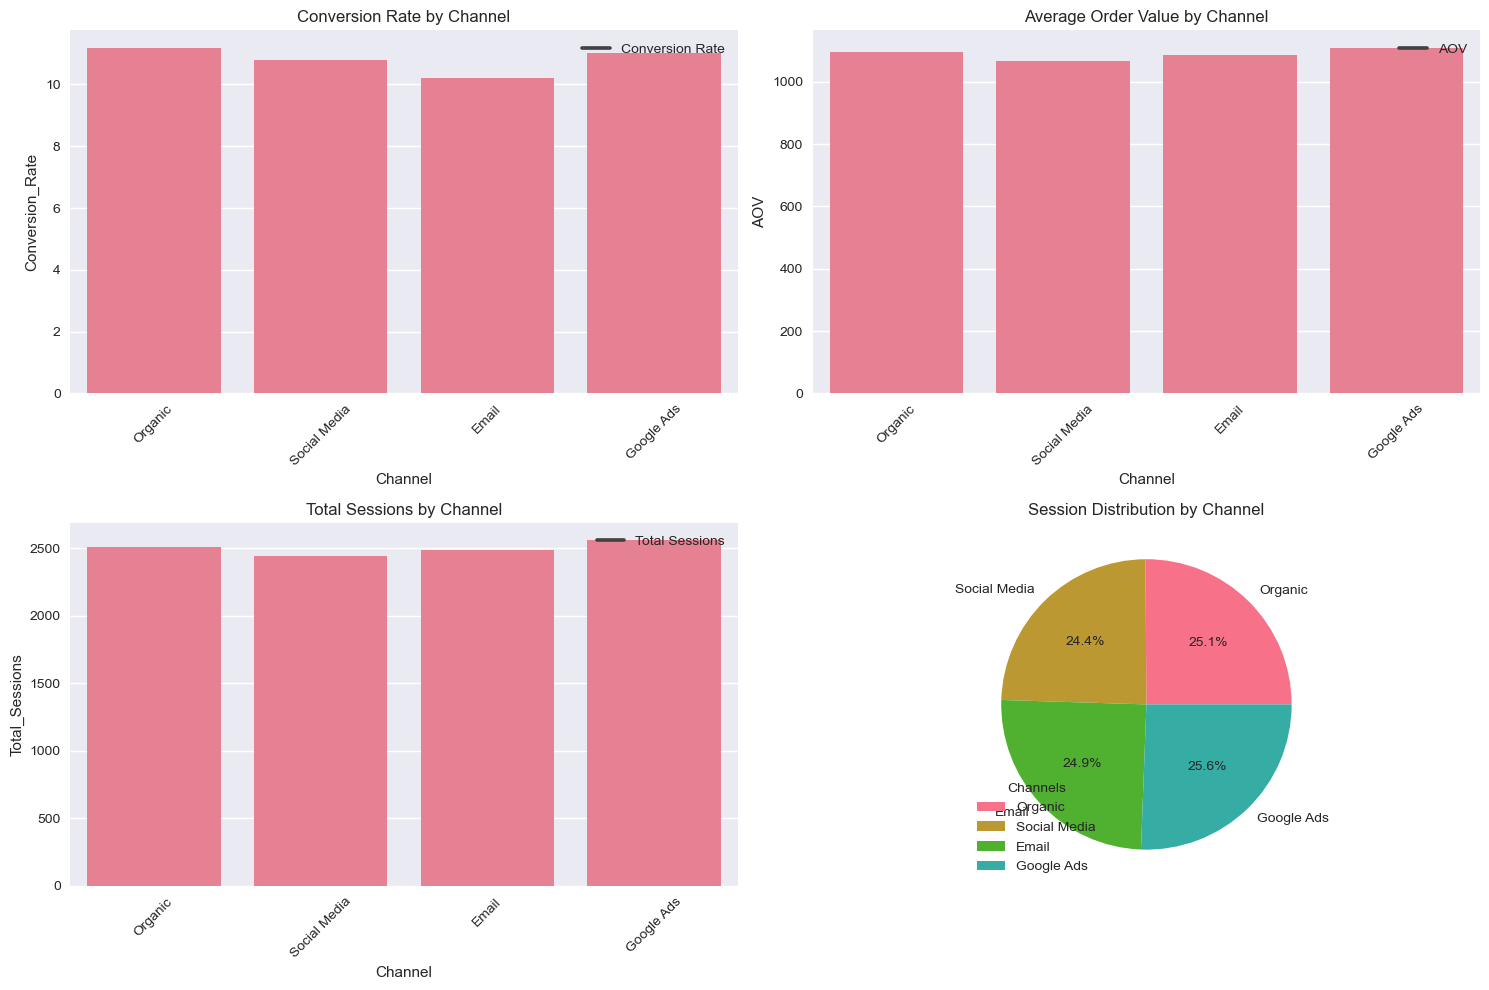

In [85]:
## Funnel analysis by channel
channel_funnel = []

for channel in df["Channel"].unique():

    channel_sessions = session_summary[
        session_summary["Channel"] == channel
    ]

    total_sessions = len(channel_sessions)

    if total_sessions > 0:

        channel_metrics = {
            "Channel": channel,
            "Total_Sessions": total_sessions
        }

        # Funnel Stage Metrics
        for i, stage in enumerate(funnel_stages):

            if i == 0:
                count = total_sessions
            else:
                count = len(
                    channel_sessions[
                        channel_sessions["Max_Funnel_Stage"].isin(funnel_stages[i:])
                    ]
                )

            channel_metrics[f"{stage}_Sessions"] = count
            channel_metrics[f"{stage}_Rate"] = count / total_sessions * 100

        # Revenue Metrics (Outside Loop)
        purchase_sessions = channel_sessions[
            channel_sessions["Max_Funnel_Stage"] == "Purchase"
        ]

        channel_metrics["Total_Revenue"] = purchase_sessions["Revenue"].sum()
        channel_metrics["AOV"] = (
            purchase_sessions["Revenue"].mean()
            if len(purchase_sessions) > 0 else 0
        )
        channel_metrics["Conversion_Rate"] = (
            len(purchase_sessions) / total_sessions * 100
        )

        channel_funnel.append(channel_metrics)

channel_df = pd.DataFrame(channel_funnel)

print("Channel Performance Analysis:")
display(channel_df.round(2))

## Visualize channel performance
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1️⃣ Conversion Rate
sns.barplot(data=channel_df, x="Channel", y="Conversion_Rate", ax=ax1)
ax1.set_title("Conversion Rate by Channel")
ax1.tick_params(axis="x", rotation=45)
ax1.legend(["Conversion Rate"])

# 2️⃣ AOV
sns.barplot(data=channel_df, x="Channel", y="AOV", ax=ax2)
ax2.set_title("Average Order Value by Channel")
ax2.tick_params(axis="x", rotation=45)
ax2.legend(["AOV"])

# 3️⃣ Total Sessions
sns.barplot(data=channel_df, x="Channel", y="Total_Sessions", ax=ax3)
ax3.set_title("Total Sessions by Channel")
ax3.tick_params(axis="x", rotation=45)
ax3.legend(["Total Sessions"])

# 4️⃣ Pie Chart
channel_df["Session_Percentage"] = (
    channel_df["Total_Sessions"] /
    channel_df["Total_Sessions"].sum() * 100
)

wedges, texts, autotexts = ax4.pie(
    channel_df["Session_Percentage"],
    labels=channel_df["Channel"],
    autopct="%1.1f%%"
)

ax4.set_title("Session Distribution by Channel")

# Legend for Pie
ax4.legend(
    wedges,
    channel_df["Channel"],
    title="Channels",
    loc="best"
)

plt.tight_layout()
plt.show()

In [ ]:
## Regional Performance Analysis
regional_analysis = session_summary.groupby("Region").agg({
    "Session_ID": "count",
    "Revenue": "sum",
    "Session_Duration_Min": "mean"
}).rename(columns={"Session_ID" : "Total_Sessions", "Revenue": "Total_Revenue"})
    
## Add conversion rates by region
regional_conversion = session_summary[session_summary["Max_Funnel_Stage"] == "Purchase"].groupby("Region").size()
regional_analysis["Converted_Sessions"] = regional_conversion
regional_analysis["Conversion_Rate"] = (regional_analysis)["Converted_Sessions"] / regional_analysis["Total_Sessions"] * 100).round(2)
regional_analysis["AOV"] = (regional_analysis["Total_Revenue"] / regional_analysis["Converted_Sessions"]).round(2)
print("Regional Performance : ")
display(regional_analysis)

## Regional Funnel Visualization
regional_funnel_data = []
for region in df["Region"].unique